In [9]:
# Bibliotecas básicas
import pandas as pd
import numpy as np
import random

import warnings

warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Estatística
from scipy import stats

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

from sklearn.model_selection import train_test_split

In [10]:
# Test Size
TEST_SIZE = 0.2

In [11]:
df_raw = pd.read_csv('../data/dataset/telco_customer_churn.csv')

df = df_raw.copy()

# Informações gerais sobre o dataset

print(f"Formato dos dados: {df.shape}")
print(f"\nPrimeiras linhas do dataset:")
print(df.head(10))

print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
print(df.info())

print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
print(df.describe())

Formato dos dados: (7043, 21)

Primeiras linhas do dataset:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... Dev

In [12]:
# Análise de valores ausentes
print("=== ANÁLISE DE MISSING VALUES ===\n")

missing_values = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
    by='Missing_Percentage', ascending=False
)

if len(missing_values) > 0:
    print(missing_values)
    
    # Visualizar missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='coral')
    plt.xlabel('Porcentagem de Missing Values (%)')
    plt.title('Distribuição de Missing Values por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum missing value detectado!")

=== ANÁLISE DE MISSING VALUES ===

Nenhum missing value detectado!


=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:
target
0    5174
1    1869
Name: count, dtype: int64

Percentual:
Sem churn (0): 73.46%
Com churn (1): 26.54%


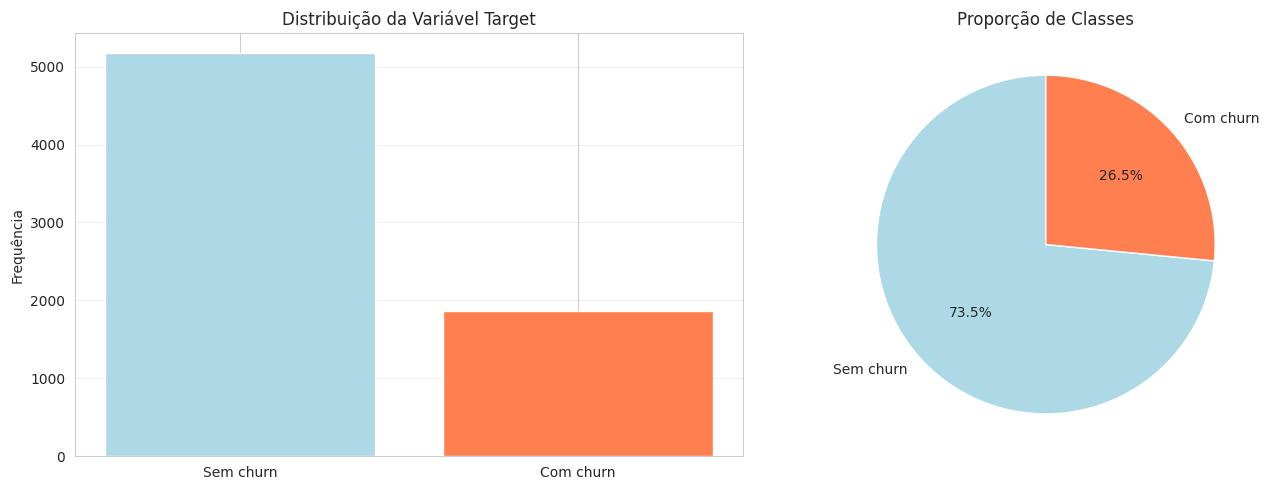


Ratio de balanceamento: 0.36
⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.


In [13]:
df.rename(columns={'Churn': 'target'}, inplace=True)

# Converter target para binário (0 = sem churn, 1 = com churn)
df['target'] = df['target'].map({'Yes': 1, 'No': 0})

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

print("Contagem:")
print(target_counts)
print("\nPercentual:")
for idx, pct in target_percentages.items():
    label = "Sem churn" if idx == 0 else "Com churn"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(['Sem churn', 'Com churn'], target_counts.values, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=['Sem churn', 'Com churn'], 
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.")
else:
    print("✓ Dataset razoavelmente balanceado.")

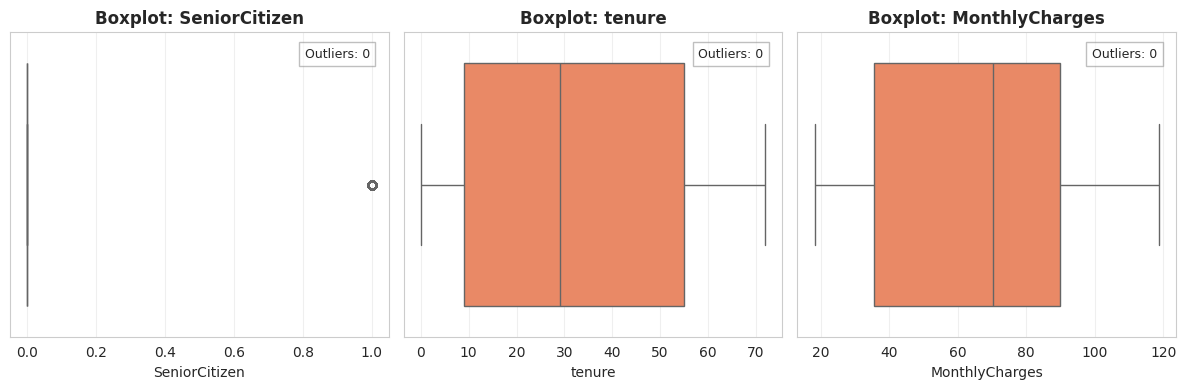

In [14]:
# Colunas numéricas (excluindo id e target)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['target'])

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [15]:
print("=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===\n")

anomalies = []

# 1. SeniorCitizen (deve ser 0 ou 1)
senior_anomalies = df[~df['SeniorCitizen'].isin([0, 1])]
if len(senior_anomalies) > 0:
    anomalies.append(('SeniorCitizen', len(senior_anomalies), 'Valores fora de {0, 1}'))

# 2. tenure (deve estar entre 0 e 72 meses)
tenure_anomalies = df[(df['tenure'] < 0) | (df['tenure'] > 72)]
if len(tenure_anomalies) > 0:
    anomalies.append(('tenure', len(tenure_anomalies), f'Fora do intervalo [0, 72] — min={df["tenure"].min()}, max={df["tenure"].max()}'))

# 3. MonthlyCharges (deve ser positivo)
monthly_anomalies = df[df['MonthlyCharges'] <= 0]
if len(monthly_anomalies) > 0:
    anomalies.append(('MonthlyCharges', len(monthly_anomalies), f'Valores <= 0 — min={df["MonthlyCharges"].min()}'))

# 4. TotalCharges (é object; verificar valores não numéricos / em branco)
total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
tc_invalid = total_charges_numeric.isna().sum()
if tc_invalid > 0:
    anomalies.append(('TotalCharges', tc_invalid, 'Valores não numéricos ou em branco'))
tc_negative = (total_charges_numeric < 0).sum()
if tc_negative > 0:
    anomalies.append(('TotalCharges', tc_negative, f'Valores negativos — min={total_charges_numeric.min()}'))

# 5. gender (deve ser Male ou Female)
gender_anomalies = df[~df['gender'].isin(['Male', 'Female'])]
if len(gender_anomalies) > 0:
    anomalies.append(('gender', len(gender_anomalies), f'Valores inesperados: {df["gender"].unique()}'))

# 6. target (deve ser 0 ou 1 após conversão)
target_anomalies = df[~df['target'].isin([0, 1])]
if len(target_anomalies) > 0:
    anomalies.append(('target', len(target_anomalies), 'Valores fora de {0, 1}'))

# 7. Colunas binárias Yes/No — verificar valores inesperados
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    col_anomalies = df[~df[col].isin(['Yes', 'No'])]
    if len(col_anomalies) > 0:
        anomalies.append((col, len(col_anomalies), f'Valores inesperados: {df[col].unique()}'))

# --- Registros duplicados ---
duplicated_count = df.duplicated().sum()

# --- Relatório ---
if anomalies:
    print(f"⚠️ Anomalias encontradas em {len(anomalies)} coluna(s):\n")
    for col, count, desc in anomalies:
        print(f"  • {col}: {count} registro(s) — {desc}")
    total_anomaly_records = sum(c for _, c, _ in anomalies)
    print(f"\n  Total de ocorrências de anomalia: {total_anomaly_records}")
else:
    print("✅ Nenhuma anomalia detectada nas verificações de domínio.")

print(f"\n📋 Registros duplicados: {duplicated_count}")
if duplicated_count > 0:
    print(f"   ({duplicated_count / len(df) * 100:.2f}% do dataset)")
else:
    print("   Nenhum registro duplicado encontrado.")

=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===

⚠️ Anomalias encontradas em 1 coluna(s):

  • TotalCharges: 11 registro(s) — Valores não numéricos ou em branco

  Total de ocorrências de anomalia: 11

📋 Registros duplicados: 0
   Nenhum registro duplicado encontrado.


=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===

        Coluna  Skewness  Kurtosis         Interpretação
 SeniorCitizen     1.834     1.363 Assimétrica à direita
        tenure     0.240    -1.387                Normal
MonthlyCharges    -0.221    -1.257                Normal


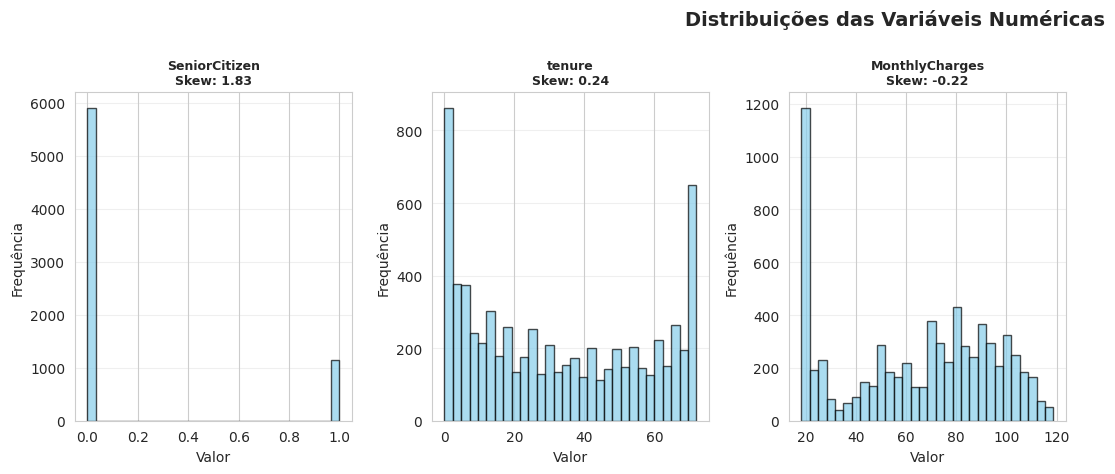

In [16]:
# Análise de distribuições
print("=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===\n")

distribution_stats = []
for col in numeric_cols:
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    distribution_stats.append({
        'Coluna': col,
        'Skewness': round(skewness, 3),
        'Kurtosis': round(kurtosis, 3),
        'Interpretação': 'Normal' if abs(skewness) < 0.5 else ('Assimétrica à direita' if skewness > 0 else 'Assimétrica à esquerda')
    })

dist_df = pd.DataFrame(distribution_stats)
print(dist_df.to_string(index=False))

# Visualizar distribuições
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}\nSkew: {df[col].skew():.2f}', fontsize=9, fontweight='bold')
        axes[idx].set_xlabel('Valor')
        axes[idx].set_ylabel('Frequência')
        axes[idx].grid(axis='y', alpha=0.3)

# Remover subplots vazios
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribuições das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

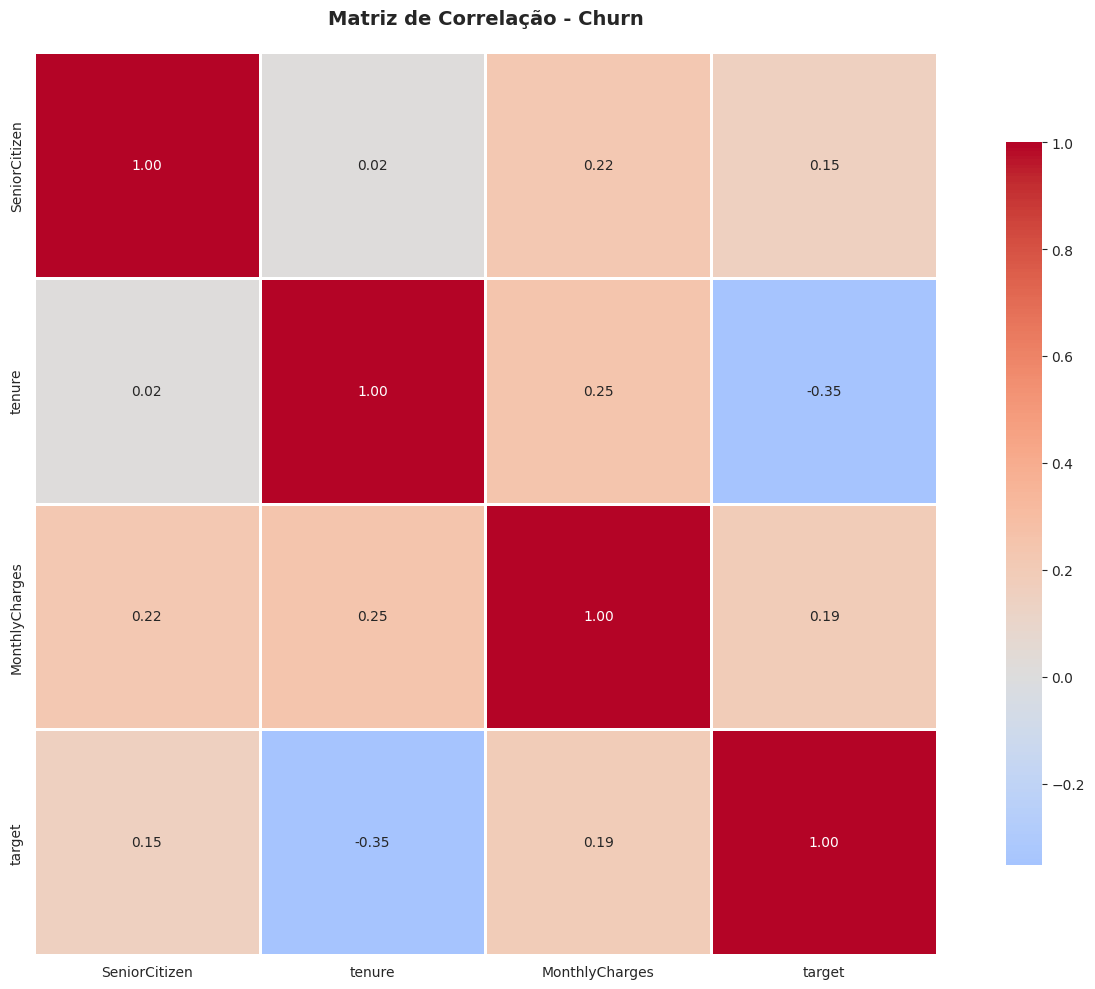

=== CORRELAÇÕES COM A VARIÁVEL TARGET ===

target            1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
tenure           -0.352229
Name: target, dtype: float64

=== MULTICOLINEARIDADE (Correlação entre features) ===
Pares de features com correlação > 0.7:

✓ Nenhuma correlação forte detectada entre features (excluindo target)


In [17]:
# Matriz de correlação apenas para colunas numéricas
corr_numeric = df.select_dtypes(include=[np.number]).corr()

# Visualizar matriz de correlação
plt.figure(figsize=(14, 10))
sns.heatmap(corr_numeric, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Churn', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlações fortes com o target
print("=== CORRELAÇÕES COM A VARIÁVEL TARGET ===\n")
target_corr = corr_numeric['target'].sort_values(ascending=False)
print(target_corr)

# Identificar pares de features com alta correlação (possível multicolinearidade)
print("\n=== MULTICOLINEARIDADE (Correlação entre features) ===")
print("Pares de features com correlação > 0.7:\n")

high_corr_pairs = []
for i in range(len(corr_numeric.columns)):
    for j in range(i+1, len(corr_numeric.columns)):
        if abs(corr_numeric.iloc[i, j]) > 0.7 and corr_numeric.columns[i] != 'target' and corr_numeric.columns[j] != 'target':
            high_corr_pairs.append({
                'Feature 1': corr_numeric.columns[i],
                'Feature 2': corr_numeric.columns[j],
                'Correlação': round(corr_numeric.iloc[i, j], 3)
            })

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlação', ascending=False)
    print(high_corr_df.to_string(index=False))
    print("\n⚠️ Alta correlação entre features pode causar multicolinearidade!")
else:
    print("✓ Nenhuma correlação forte detectada entre features (excluindo target)")

In [18]:
# Remoção da Coluna de ID
df.drop(columns=['customerID'], inplace=True)

# Tratar coluna TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
mask = df['TotalCharges'].isna()
df.loc[mask, 'TotalCharges'] = df.loc[mask, 'MonthlyCharges'] * df.loc[mask, 'tenure']

# Categorical Cols
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)

Treino original: {0: 4139, 1: 1495}
Teste: {0: 1035, 1: 374}

Após SMOTE: {0: 4139, 1: 4139}
Após Undersampling: {0: 1495, 1: 1495}

=== COMPARAÇÃO DAS TÉCNICAS DE BALANCEAMENTO ===

Sem balanceamento    → F1-score (churn): 0.6020
SMOTE                → F1-score (churn): 0.5787
class_weight         → F1-score (churn): 0.6146
Undersampling        → F1-score (churn): 0.6160


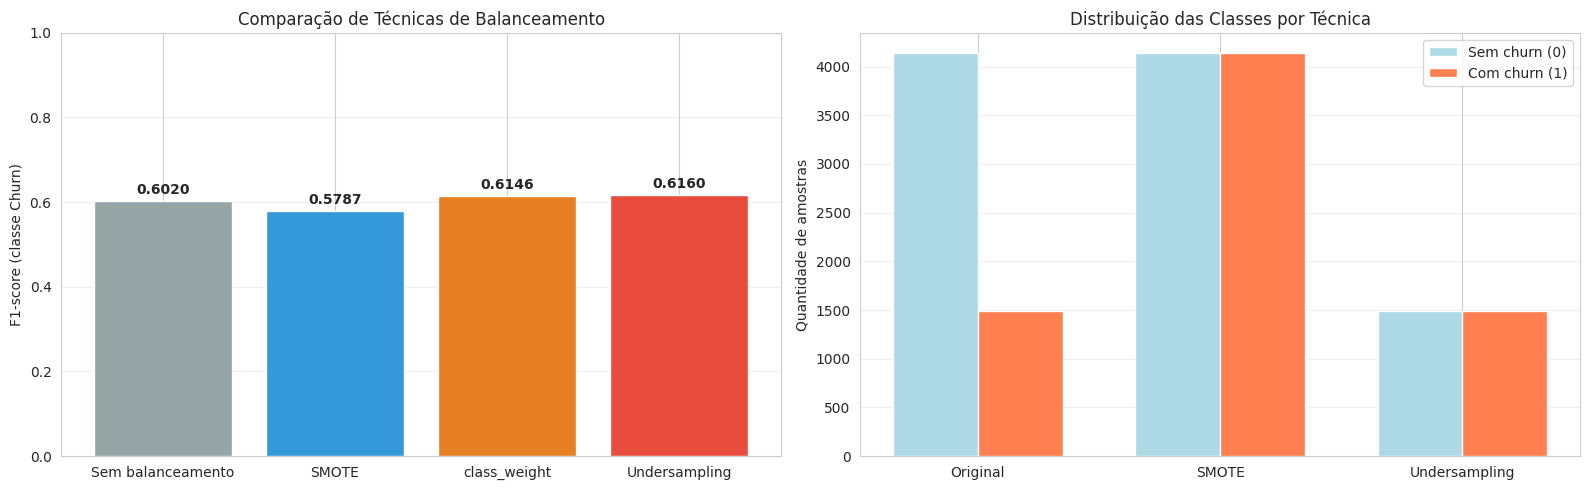


✅ Melhor F1-score para churn: Undersampling (0.6160)

📌 Resumo:
  • SMOTE: cria dados sintéticos → mais amostras, mas pode gerar ruído
  • class_weight: ajusta o custo do erro → simples, sem alterar os dados
  • Undersampling: remove dados da maioria → rápido, mas perde informação



In [19]:
# =============================================================================
# TÉCNICAS DE BALANCEAMENTO DO DATASET
# O dataset está desbalanceado (73% vs 27%), o que pode fazer o modelo
# "viciar" na classe majoritária. Vamos comparar 3 abordagens:
#   1. SMOTE (Synthetic Minority Oversampling Technique)
#   2. class_weight (ajuste de pesos no algoritmo)
#   3. Random Undersampling (reduzir a classe majoritária)
#
# IMPORTANTE: O rebalanceamento é aplicado APENAS no conjunto de treino.
#             O conjunto de teste permanece com a distribuição original
#             para refletir o cenário real de produção.
# =============================================================================
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

print(f"Treino original: {y_train.value_counts().to_dict()}")
print(f"Teste: {y_test.value_counts().to_dict()}\n")

# =============================================================================
# 1. SMOTE — gera amostras SINTÉTICAS da classe minoritária
#    Interpola entre exemplos reais de churn para criar novos pontos,
#    aumentando a classe minoritária até igualar a majoritária.
# =============================================================================
smote = SMOTE(random_state=SEED)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print(f"Após SMOTE: {pd.Series(y_smote).value_counts().to_dict()}")

# =============================================================================
# 2. CLASS_WEIGHT='balanced' — não altera os dados, altera o custo do erro
#    O algoritmo penaliza mais os erros na classe minoritária,
#    proporcionalmente ao inverso da frequência de cada classe.
# =============================================================================
# (aplicado diretamente no modelo, sem reamostrar)

# =============================================================================
# 3. RANDOM UNDERSAMPLING — remove amostras aleatórias da classe majoritária
#    Reduz a classe "Sem churn" até igualar a quantidade de "Com churn".
#    Simples, mas perde informação da classe majoritária.
# =============================================================================
rus = RandomUnderSampler(random_state=SEED)
X_under, y_under = rus.fit_resample(X_train, y_train)
print(f"Após Undersampling: {pd.Series(y_under).value_counts().to_dict()}")

# --- Treinar Logistic Regression para comparar as técnicas ---
resultados = {}

# Baseline: sem balanceamento
clf_base = LogisticRegression(max_iter=1000, random_state=SEED)
clf_base.fit(X_train, y_train)
y_pred_base = clf_base.predict(X_test)
resultados['Sem balanceamento'] = f1_score(y_test, y_pred_base, pos_label=1)

# SMOTE
clf_smote = LogisticRegression(max_iter=1000, random_state=SEED)
clf_smote.fit(X_smote, y_smote)
y_pred_smote = clf_smote.predict(X_test)
resultados['SMOTE'] = f1_score(y_test, y_pred_smote, pos_label=1)

# class_weight='balanced'
clf_weight = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
clf_weight.fit(X_train, y_train)
y_pred_weight = clf_weight.predict(X_test)
resultados['class_weight'] = f1_score(y_test, y_pred_weight, pos_label=1)

# Undersampling
clf_under = LogisticRegression(max_iter=1000, random_state=SEED)
clf_under.fit(X_under, y_under)
y_pred_under = clf_under.predict(X_test)
resultados['Undersampling'] = f1_score(y_test, y_pred_under, pos_label=1)

# --- Comparação visual ---
print("\n=== COMPARAÇÃO DAS TÉCNICAS DE BALANCEAMENTO ===\n")
for tecnica, score in resultados.items():
    print(f"{tecnica:20s} → F1-score (churn): {score:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# F1-score por técnica
cores = ['#95a5a6', '#3498db', '#e67e22', '#e74c3c']
bars = axes[0].bar(resultados.keys(), resultados.values(), color=cores)
axes[0].set_ylabel('F1-score (classe Churn)')
axes[0].set_title('Comparação de Técnicas de Balanceamento')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, resultados.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Distribuição das classes em cada abordagem
distribuicoes = {
    'Original': [y_train.value_counts()[0], y_train.value_counts()[1]],
    'SMOTE': [pd.Series(y_smote).value_counts()[0], pd.Series(y_smote).value_counts()[1]],
    'Undersampling': [pd.Series(y_under).value_counts()[0], pd.Series(y_under).value_counts()[1]],
}
x_pos = np.arange(len(distribuicoes))
width = 0.35
axes[1].bar(x_pos - width/2, [d[0] for d in distribuicoes.values()], width,
            label='Sem churn (0)', color='lightblue')
axes[1].bar(x_pos + width/2, [d[1] for d in distribuicoes.values()], width,
            label='Com churn (1)', color='coral')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(distribuicoes.keys())
axes[1].set_ylabel('Quantidade de amostras')
axes[1].set_title('Distribuição das Classes por Técnica')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --- Resumo ---
melhor = max(resultados, key=resultados.get)
print(f"\n✅ Melhor F1-score para churn: {melhor} ({resultados[melhor]:.4f})")
print("""
📌 Resumo:
  • SMOTE: cria dados sintéticos → mais amostras, mas pode gerar ruído
  • class_weight: ajusta o custo do erro → simples, sem alterar os dados
  • Undersampling: remove dados da maioria → rápido, mas perde informação
""")

In [20]:
import pandas as pd

df_raw = pd.read_csv("../data/dataset/telco_customer_churn.csv")
df = df_raw.copy()

df_work = df.copy()
df_work["TotalCharges"] = pd.to_numeric(df_work["TotalCharges"], errors="coerce")

## Análise exploratória complementar

Nesta seção, vamos aprofundar a análise do dataset sem repetir as etapas já realizadas no EDA inicial. O foco será em `TotalCharges`, relações com `Churn`, variáveis categóricas, variáveis numéricas e correlações.

In [21]:
df_work = df.copy()
df_work["TotalCharges"] = pd.to_numeric(df_work["TotalCharges"], errors="coerce")

In [22]:
print("=== VERIFICAÇÃO DE TotalCharges ===")
print(f"Valores inválidos em TotalCharges: {df_work['TotalCharges'].isna().sum()}")
display(df_work[df_work["TotalCharges"].isna()].head())

=== VERIFICAÇÃO DE TotalCharges ===
Valores inválidos em TotalCharges: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No


## Análise descritiva de TotalCharges

Aqui avaliamos a distribuição de `TotalCharges` após a conversão para numérico. Essa variável costuma ser importante porque combina tempo de contrato e valor mensal, ajudando a explicar comportamento de churn.

In [23]:
print("=== ESTATÍSTICAS DESCRITIVAS DE TotalCharges ===")
display(df_work["TotalCharges"].describe())

print("\n=== ASSIMETRIA E CURTOSE ===")
print(f"Skewness: {df_work['TotalCharges'].skew():.4f}")
print(f"Kurtosis: {df_work['TotalCharges'].kurtosis():.4f}")

=== ESTATÍSTICAS DESCRITIVAS DE TotalCharges ===


count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64


=== ASSIMETRIA E CURTOSE ===
Skewness: 0.9616
Kurtosis: -0.2318


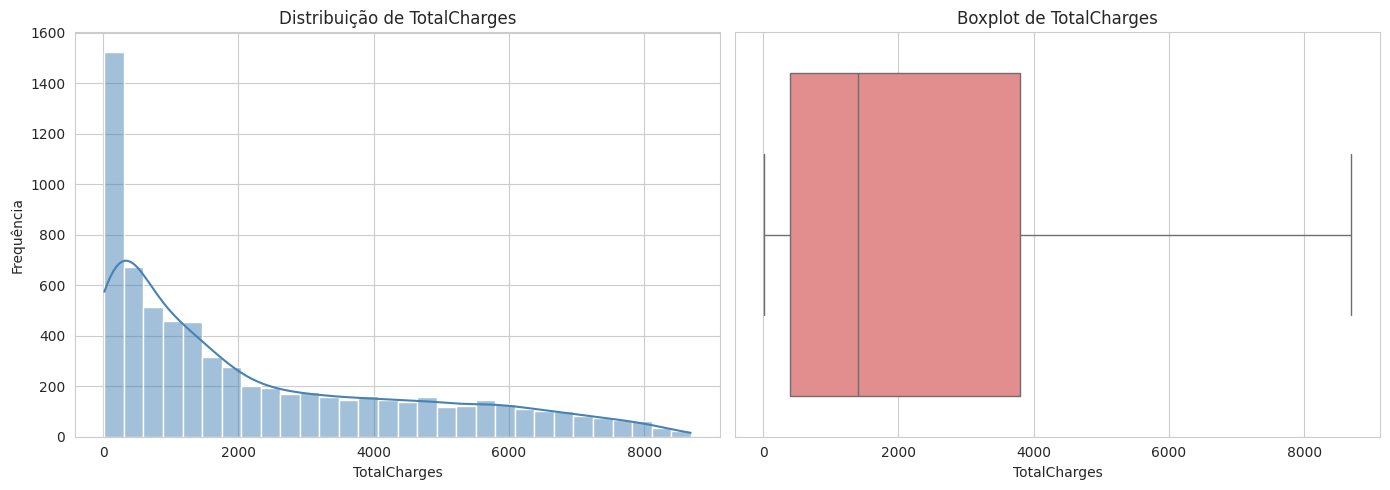

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_work["TotalCharges"].dropna(), bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribuição de TotalCharges")
axes[0].set_xlabel("TotalCharges")
axes[0].set_ylabel("Frequência")

sns.boxplot(x=df_work["TotalCharges"], ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot de TotalCharges")
axes[1].set_xlabel("TotalCharges")

plt.tight_layout()
plt.show()

## TotalCharges por churn

Agora vamos comparar `TotalCharges` entre clientes com e sem churn. Essa análise ajuda a entender se clientes que saem tendem a ter padrões diferentes de gasto acumulado.

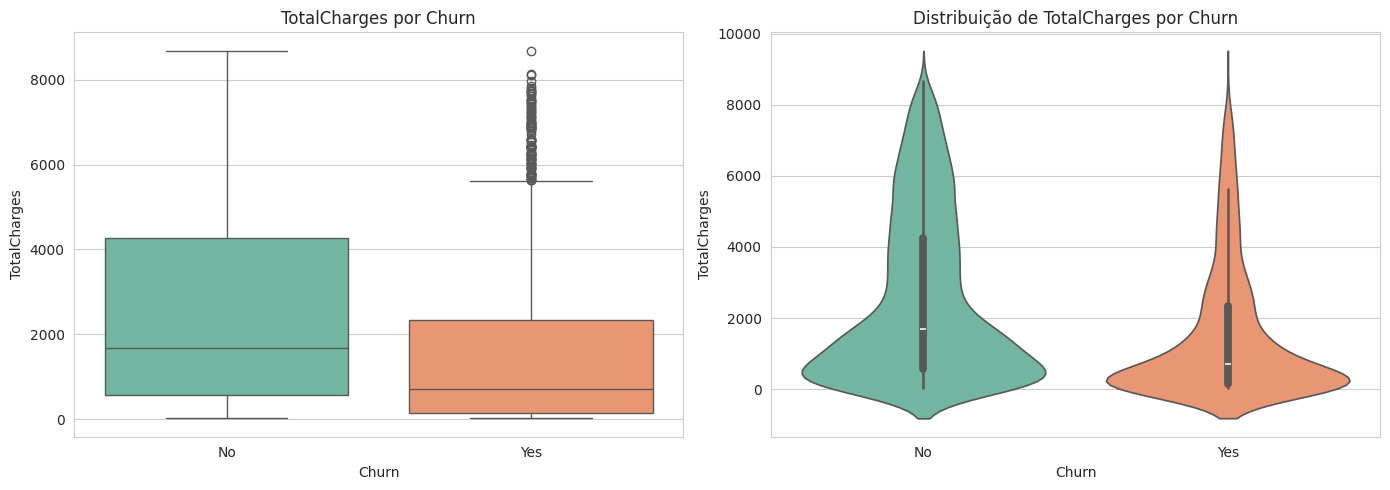

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_work, x="Churn", y="TotalCharges", ax=axes[0], palette="Set2")
axes[0].set_title("TotalCharges por Churn")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("TotalCharges")

sns.violinplot(data=df_work, x="Churn", y="TotalCharges", ax=axes[1], palette="Set2")
axes[1].set_title("Distribuição de TotalCharges por Churn")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("TotalCharges")

plt.tight_layout()
plt.show()

In [26]:
print("=== MÉDIA DE TotalCharges POR CHURN ===")
display(
    df_work.groupby("Churn")["TotalCharges"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

=== MÉDIA DE TotalCharges POR CHURN ===


,count,mean,median,std,min,max
Churn,,,,,,
No,5163,2555.34,1683.60,2329.46,18.80,8672.45
Yes,1869,1531.80,703.55,1890.82,18.85,8684.80


## Variáveis categóricas e churn

Nesta parte, vamos comparar a proporção de churn nas principais variáveis categóricas. O objetivo é detectar padrões que possam indicar maior risco de cancelamento.

<Figure size 1000x400 with 0 Axes>

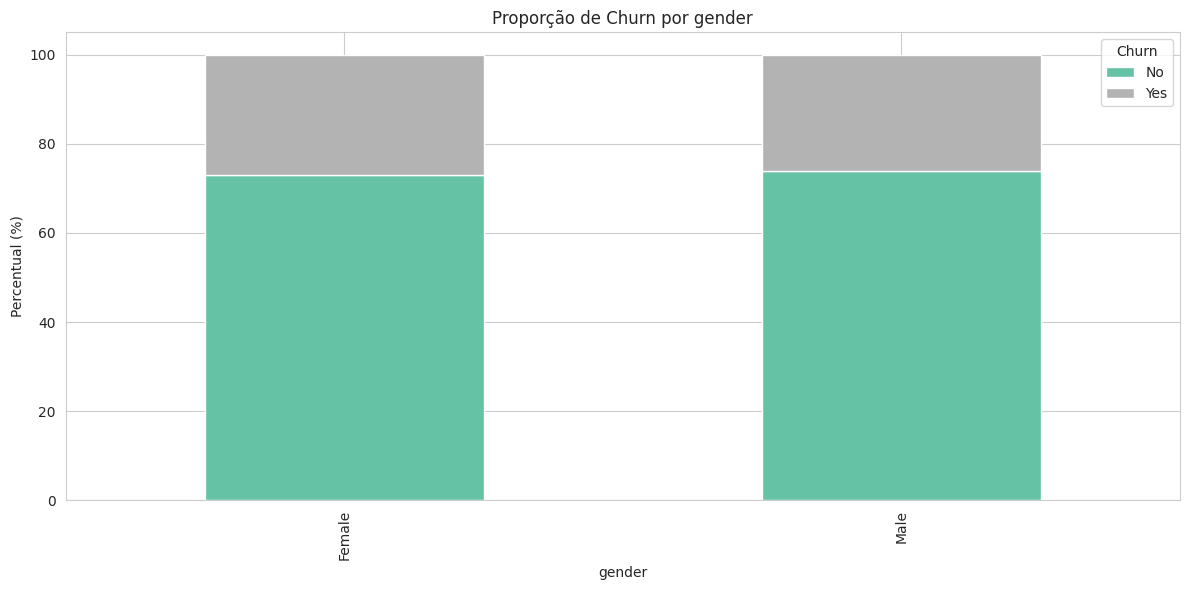

<Figure size 1000x400 with 0 Axes>

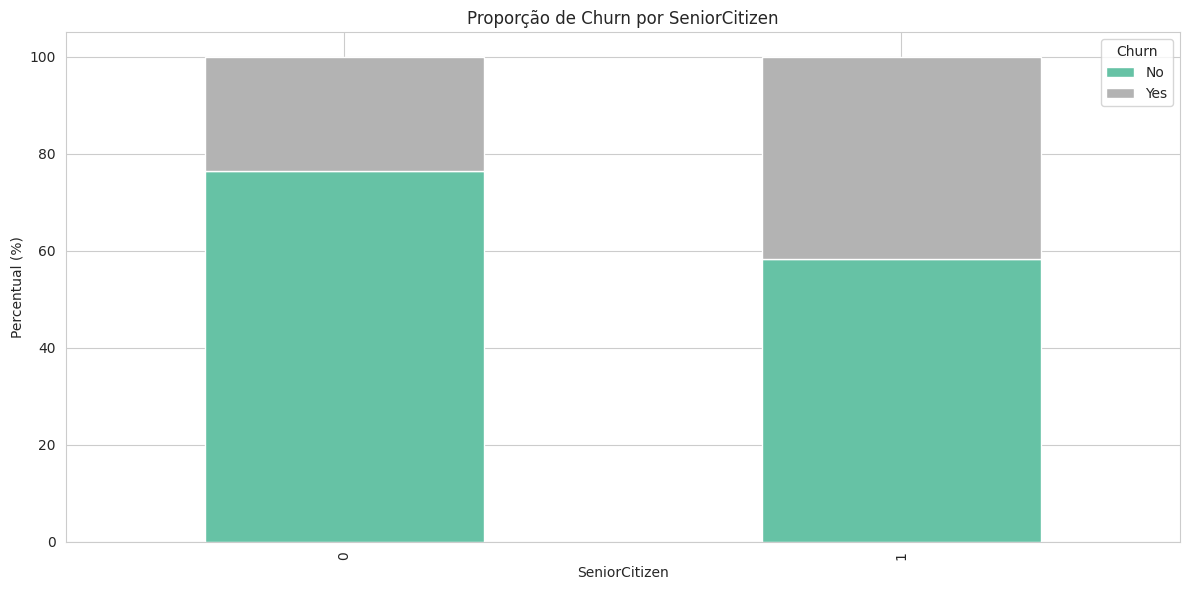

<Figure size 1000x400 with 0 Axes>

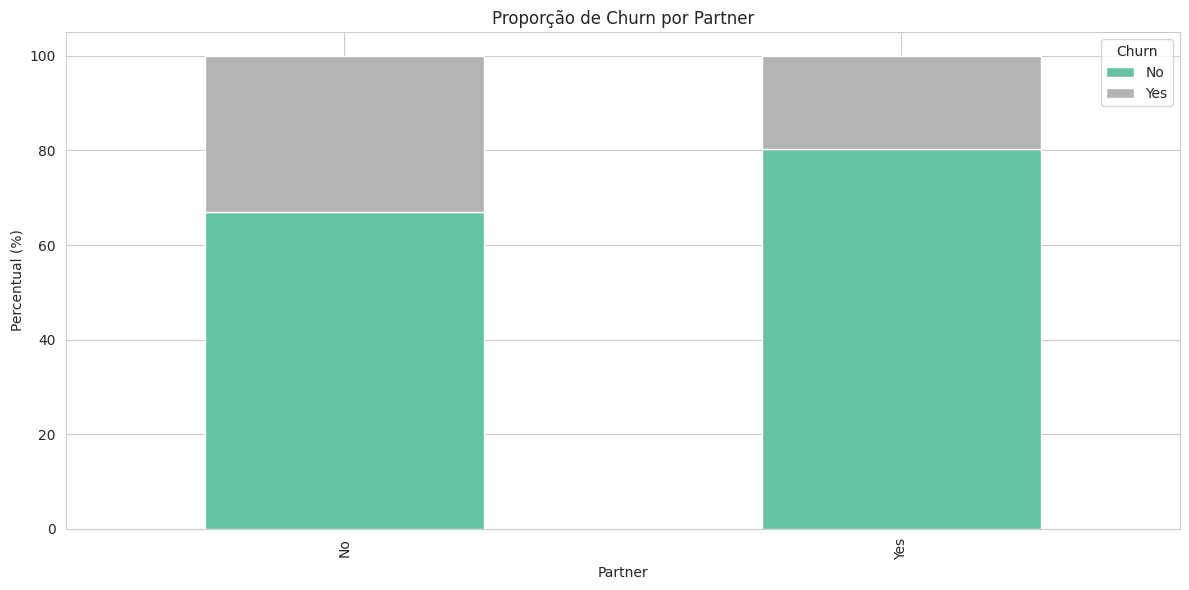

<Figure size 1000x400 with 0 Axes>

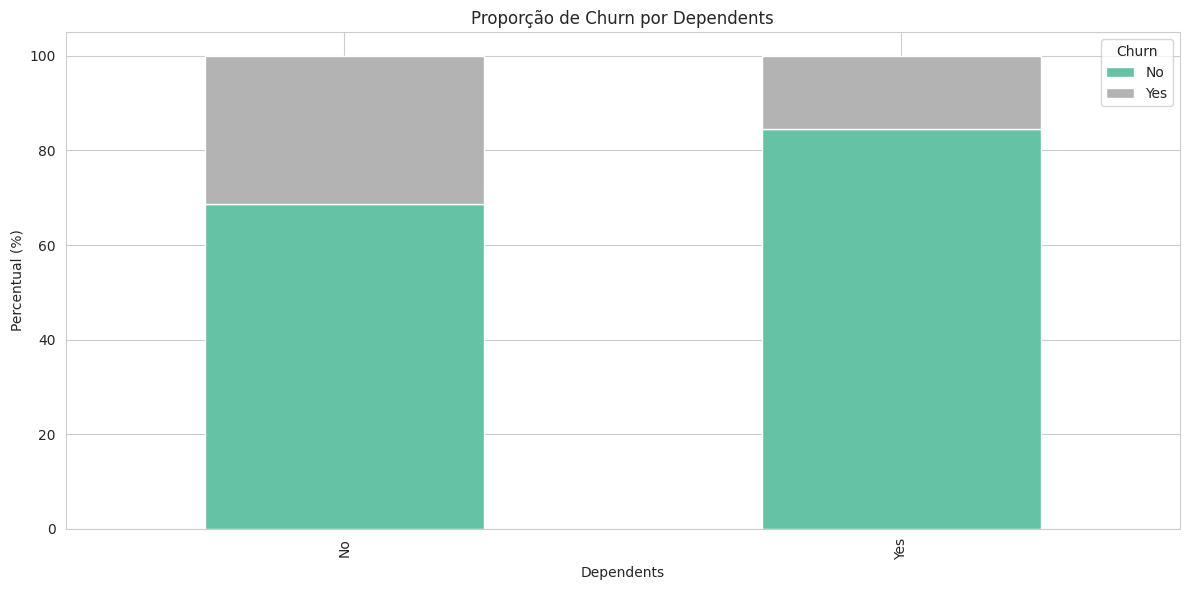

<Figure size 1000x400 with 0 Axes>

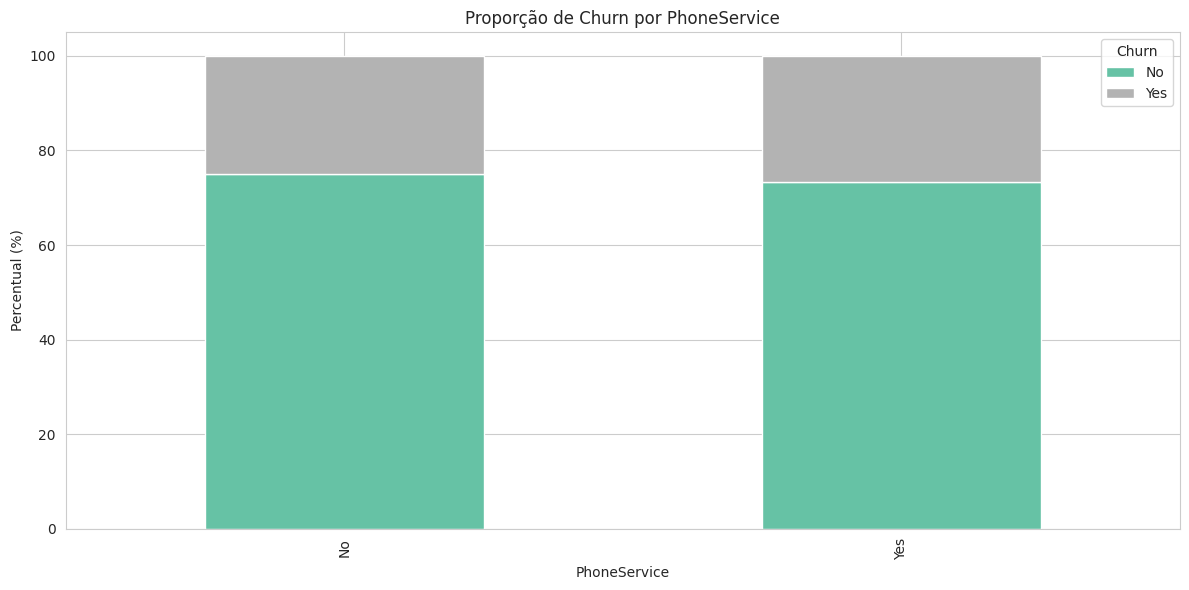

<Figure size 1000x400 with 0 Axes>

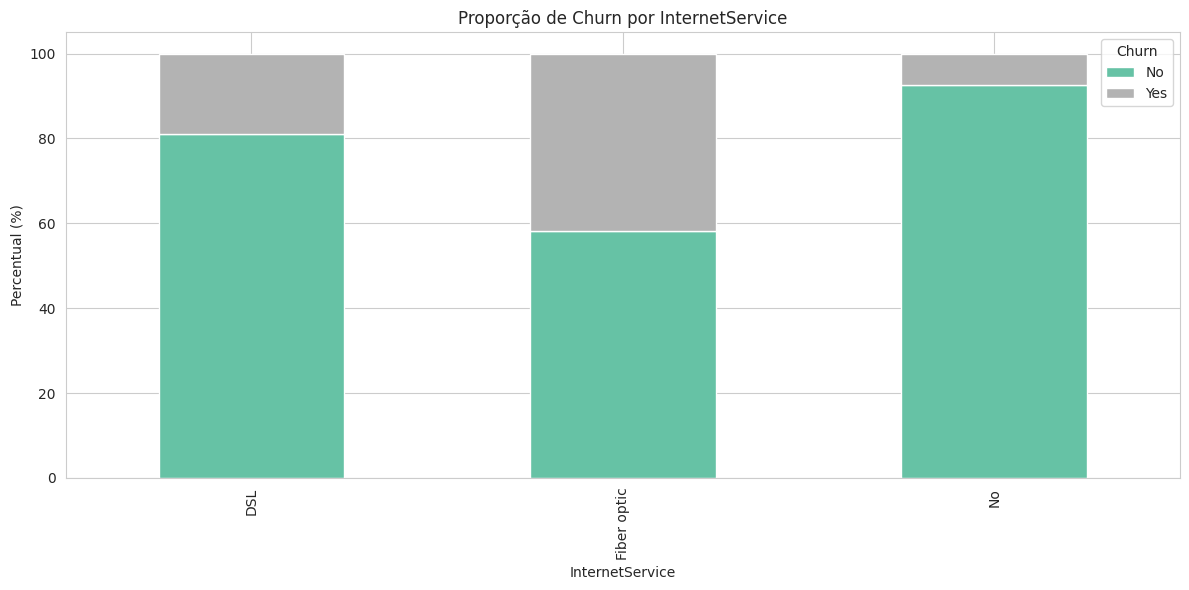

<Figure size 1000x400 with 0 Axes>

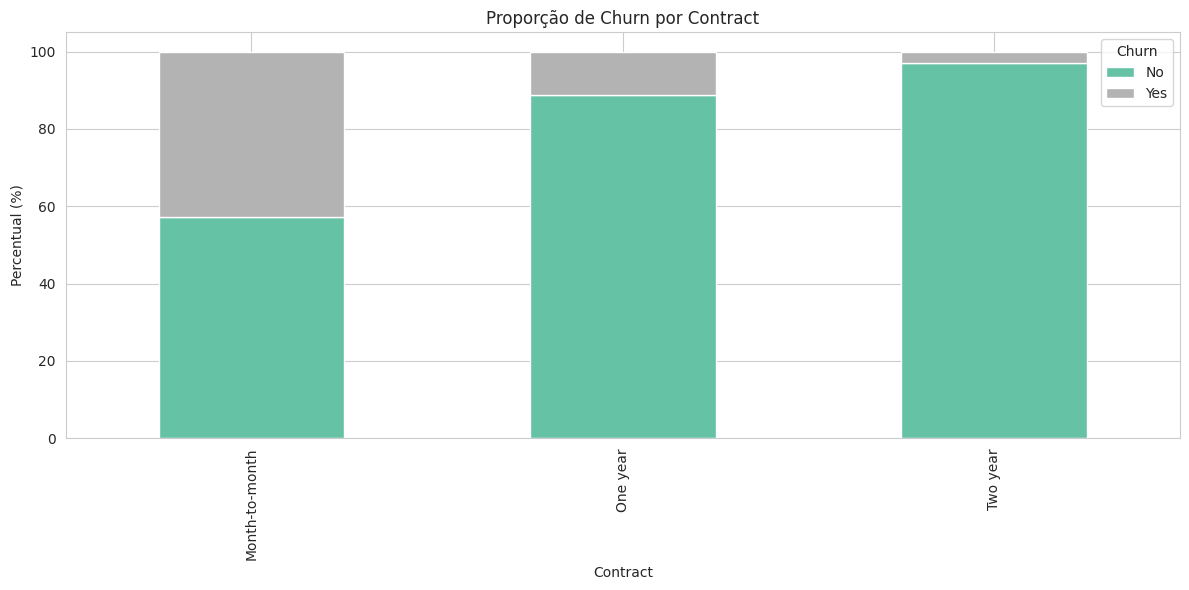

<Figure size 1000x400 with 0 Axes>

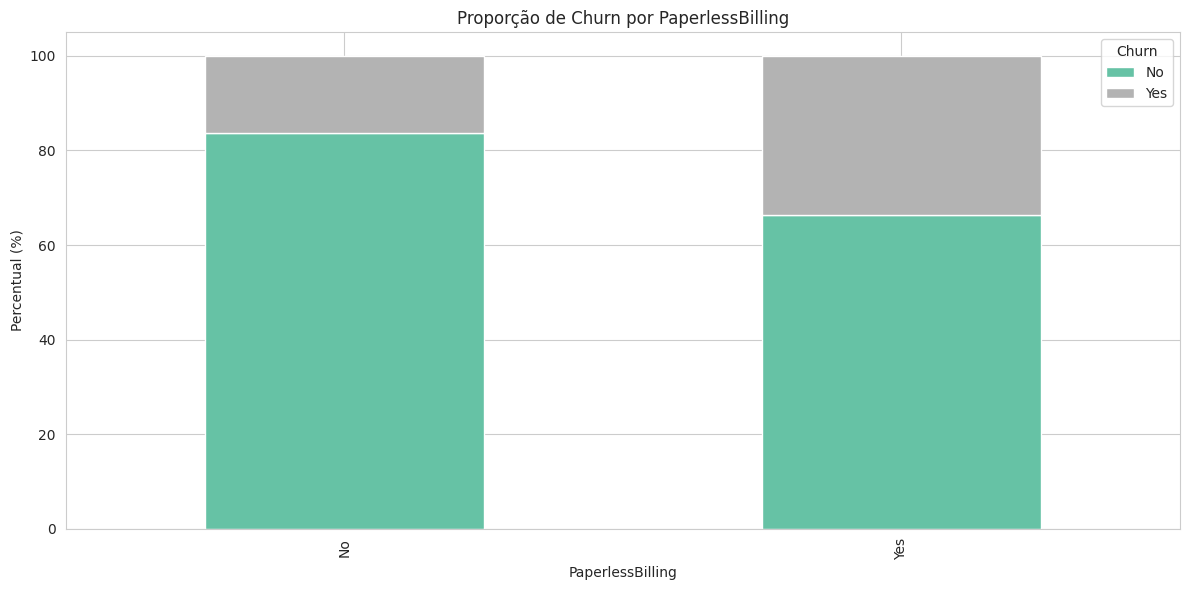

<Figure size 1000x400 with 0 Axes>

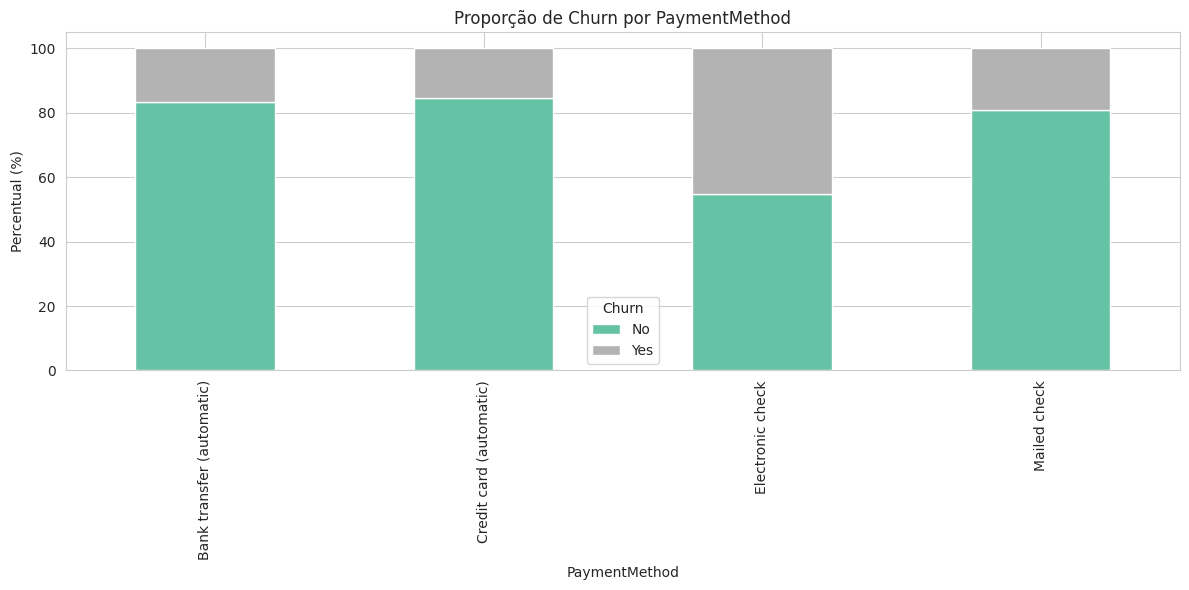

In [27]:
categorical_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "InternetService",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    churn_prop = pd.crosstab(df_work[col], df_work["Churn"], normalize="index") * 100
    churn_prop.plot(kind="bar", stacked=True, colormap="Set2")
    plt.title(f"Proporção de Churn por {col}")
    plt.xlabel(col)
    plt.ylabel("Percentual (%)")
    plt.legend(title="Churn")
    plt.tight_layout()
    plt.show()

In [28]:
print("=== TABELAS DE PROPORÇÃO DE CHURN ===")
for col in ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"]:
    print(f"\n--- {col} ---")
    display(pd.crosstab(df_work[col], df_work["Churn"], normalize="index").round(4))

=== TABELAS DE PROPORÇÃO DE CHURN ===

--- Contract ---


Churn,No,Yes
Contract,,
Month-to-month,0.5729,0.4271
One year,0.8873,0.1127
Two year,0.9717,0.0283



--- InternetService ---


Churn,No,Yes
InternetService,,
DSL,0.8104,0.1896
Fiber optic,0.5811,0.4189
No,0.9260,0.0740



--- PaymentMethod ---


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.8329,0.1671
Credit card (automatic),0.8476,0.1524
Electronic check,0.5471,0.4529
Mailed check,0.8089,0.1911



--- PaperlessBilling ---


Churn,No,Yes
PaperlessBilling,,
No,0.8367,0.1633
Yes,0.6643,0.3357


## Variáveis numéricas e churn

Aqui vamos observar como `tenure`, `MonthlyCharges` e `TotalCharges` se comportam entre os grupos de churn. Essas variáveis costumam mostrar diferenças relevantes entre clientes que permanecem e clientes que cancelam.

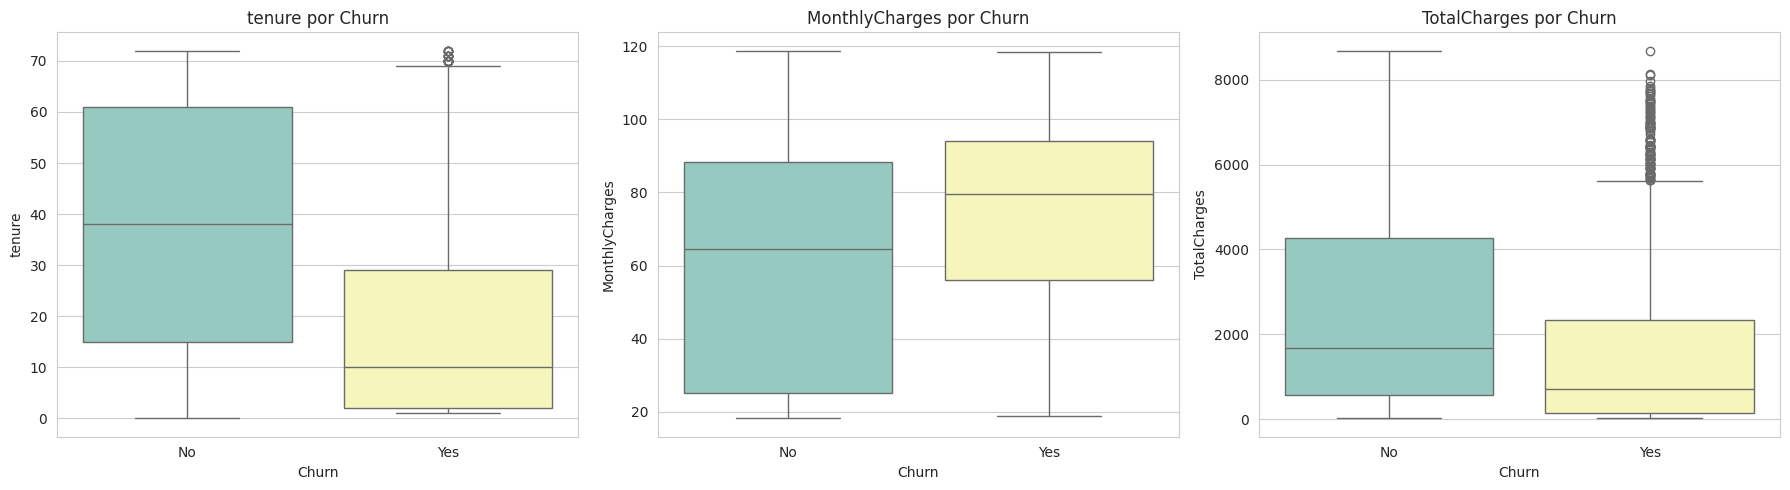

In [29]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_work, x="Churn", y=col, ax=axes[i], palette="Set3")
    axes[i].set_title(f"{col} por Churn")
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [30]:
print("=== RESUMO NUMÉRICO POR CHURN ===")
display(
    df_work.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]]
    .agg(["mean", "median", "std"])
    .round(2)
)

=== RESUMO NUMÉRICO POR CHURN ===


tenure               MonthlyCharges               TotalCharges           \
        mean median    std           mean median    std         mean   median   
Churn                                                                           
No     37.57   38.0  24.11          61.27  64.43  31.09      2555.34  1683.60   
Yes    17.98   10.0  19.53          74.44  79.65  24.67      1531.80   703.55   

                
           std  
Churn           
No     2329.46  
Yes    1890.82

## Correlação entre variáveis numéricas

Esta etapa mede a força da relação linear entre as variáveis numéricas. Ela ajuda a identificar dependências e possíveis redundâncias antes da modelagem.

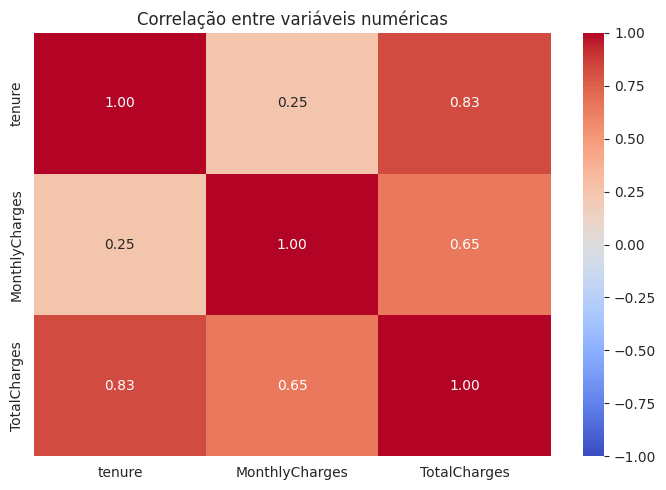

In [31]:
corr = df_work[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

In [32]:
print("=== MATRIZ DE CORRELAÇÃO ===")
display(corr.round(4))

=== MATRIZ DE CORRELAÇÃO ===


,tenure,MonthlyCharges,TotalCharges
tenure,1.0000,0.2479,0.8259
MonthlyCharges,0.2479,1.0000,0.6511
TotalCharges,0.8259,0.6511,1.0000


## Interpretação parcial

Os gráficos acima permitem comparar padrões de gasto, tempo de permanência e tipo de contrato entre clientes que cancelam e os que permanecem.  


In [33]:
# Criar uma cópia de trabalho
df_work = df.copy()

# Converter TotalCharges para numérico
df_work['TotalCharges'] = pd.to_numeric(df_work['TotalCharges'], errors='coerce')

# Remover linhas com TotalCharges ausente após conversão
df_work = df_work.dropna(subset=['TotalCharges'])

# Garantir target binário
df_work['target'] = df_work['Churn'].map({'No': 0, 'Yes': 1})

print('Formato após tratamento:', df_work.shape)
print('Valores ausentes em TotalCharges:', df_work['TotalCharges'].isna().sum())
print('Distribuição do target:')
print(df_work['target'].value_counts())

Formato após tratamento: (7032, 22)
Valores ausentes em TotalCharges: 0
Distribuição do target:
target
0    5163
1    1869
Name: count, dtype: int64


=== RESUMO DAS VARIÁVEIS POR TARGET ===
       tenure               MonthlyCharges               TotalCharges  \
         mean median    std           mean median    std         mean   
target                                                                  
0       37.65   38.0  24.08          61.31  64.45  31.09      2555.34   
1       17.98   10.0  19.53          74.44  79.65  24.67      1531.80   

                          
         median      std  
target                    
0       1683.60  2329.46  
1        703.55  1890.82  


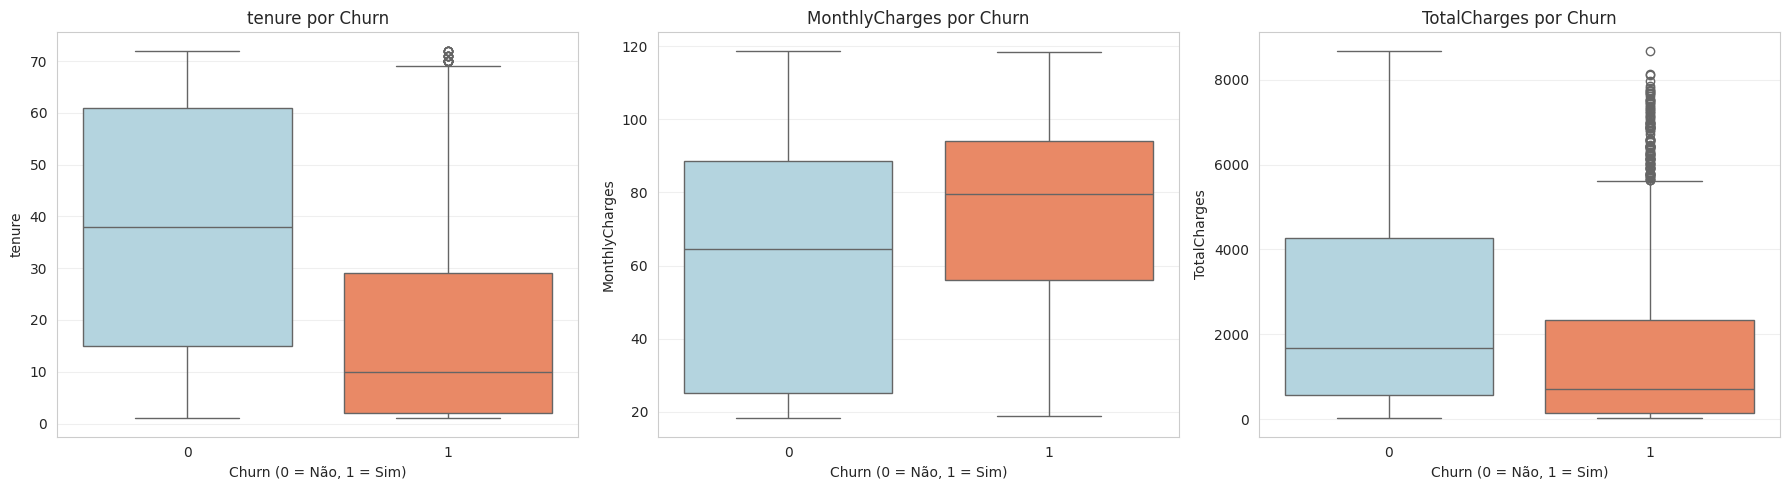

In [34]:
# Comparação das variáveis numéricas por churn
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

summary_churn = df_work.groupby('target')[numeric_cols].agg(['mean', 'median', 'std']).round(2)
print('=== RESUMO DAS VARIÁVEIS POR TARGET ===')
print(summary_churn)

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df_work, x='target', y=col, ax=ax, palette=['lightblue', 'coral'])
    ax.set_title(f'{col} por Churn')
    ax.set_xlabel('Churn (0 = Não, 1 = Sim)')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# Teste simples de diferença entre grupos
from scipy.stats import mannwhitneyu

for col in numeric_cols:
    g0 = df_work[df_work['target'] == 0][col]
    g1 = df_work[df_work['target'] == 1][col]
    stat, pvalue = mannwhitneyu(g0, g1, alternative='two-sided')
    print(f'{col}: p-value = {pvalue:.4e}')

tenure: p-value = 6.0430e-211
MonthlyCharges: p-value = 8.4672e-54
TotalCharges: p-value = 1.9960e-84


## Análise das variáveis numéricas

Após tratar `TotalCharges`, comparo as variáveis numéricas mais relevantes entre clientes com e sem churn. Essa etapa ajuda a entender se há diferença de comportamento entre os grupos antes da modelagem.

Os boxplots mostram como `tenure`, `MonthlyCharges` e `TotalCharges` se distribuem por classe. Em geral, clientes com churn tendem a apresentar menor permanência e padrões diferentes de cobrança ao longo do tempo.